## Trees and Ensembles: Comparison

In this part we compare the four tree models of the `1B` notebooks with the baseline: the pruned tree (`1B1_pruned_cart`), the bagging (`1B2_bagging`), the random forest (`1B3_random_forest`) and the Extra-Trees (`1B4_extra_trees`). Nothing is trained here: each model is tuned and evaluated in its own notebook, which adds its rows to `results.csv`, and this notebook only reads that table.

### Tuned hyperparameters

| Model | Tuned per target on the folds of `helpers/utils.py` | Selected |
|---|---|---|
| Pruned CART | `ccp_alpha`, every value of the pruning path (287 to 507 values per target) | 29 to 270 leaves |
| Bagging | `max_samples` and `max_features` in {0.25, 0.5, 0.75, 1.0} | 1.0 and 1.0 for the 4 targets, the classic bagging |
| Random forest | `max_features` in {0.1, 0.2, 0.33, 0.5, 0.75, 1.0} and `min_samples_leaf` in {1, 2, 4, 8} | `max_features` of 0.5 (yield strength, UTS) or 0.75 (elongation, Charpy), `min_samples_leaf` of 1 |
| Extra-Trees | Same grid as the random forest | `max_features` of 0.5 (tensile targets) or 1.0 (Charpy), `min_samples_leaf` of 1 |

The three ensembles use 200 trees, chosen on the curves of the validation MAE against the number of trees (within 1% of the MAE with 500 trees on every target).

### Main observations

- **Ranking:** The Extra-Trees have the lowest MAE on every target: 29.1 MPa on the yield strength, 25.2 MPa on the UTS, 1.78% on the elongation and 17.4 J on the Charpy energy, from 55% to 66% below the baseline. On the tensile targets, the order is Extra-Trees, then random forest and bagging (close to each other), then the pruned tree.
- **Averaging:** From the pruned tree to the bagging, the MAE of the tensile targets drops by 25% to 27%, the largest step of the series. Drawing the inputs at each split (random forest) only adds 0% to 4%, drawing the thresholds at random (Extra-Trees) another 8% to 15%.
- **Charpy:** The bagging and the random forest are not better than the pruned tree (19.1 against 18.9 J) and the Extra-Trees only 8% better (17.4 J). The ensembles also miss most non-conforming Charpy rows (recall from 0.10 to 0.17, against 0.62 for the pruned tree). The mean of 200 trees pulls the energy predicted at the reference temperature above the 47 J threshold.
- **label:** The Extra-Trees have the best F1 (0.84, against 0.64 for the rule that declares every weld non-conforming) and the pruned tree the best recall (0.81), it catches more bad welds at the cost of more false alarms.
- **Cr-Mo welds:** Every model is much worse on the Cr-Mo welds than on the C-Mn welds, with only 35 CrMo2 and 41 CrMo91 deposits in the train set. For the Extra-Trees, the MAE of the yield strength is 44.7 MPa on the CrMo2 welds, against 27.1 MPa on the C-Mn welds.

### Operations in order

1. Load `results.csv` with `load_results` and keep the baseline and the four tree models.
2. Compare the MAE and the RMSE per target, and the change of the MAE from one model to the next.
3. Plot the MAE of each model per target, with its standard deviation over the 5 folds.
4. Compare the MAE per alloy family.
5. Compare the F1 and the recall on the non-conforming welds, per criterion and for the full label, then for the label per family.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append("..")  # helpers/ is in modeling/

from helpers.utils import TARGETS, REPORT_FAMILIES, load_results

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)

In [3]:
models = ["Baseline (mean)", "Pruned CART", "Bagging", "Random forest", "Extra-Trees"]

results = load_results()
results = results[results["model"].isin(models)].set_index(["model", "target", "family"])
overall = results.xs("all", level="family")
mae = overall["MAE"].unstack().reindex(index=models, columns=TARGETS)

display(overall[["MAE", "RMSE"]].unstack().reindex(index=models).reindex(columns=TARGETS, level="target").round(2))
display((100 * (mae / mae.loc["Baseline (mean)"] - 1)).round(1))
(100 * (mae / mae.shift() - 1)).round(1)

MAE                                            \
target          yield_strength_MPa uts_MPa elongation_pct charpy_toughness_J   
model                                                                          
Baseline (mean)              72.57   73.45           4.01              39.89   
Pruned CART                  48.24   41.78           2.60              18.87   
Bagging                      35.24   30.86           1.95              19.11   
Random forest                33.95   29.55           1.94              19.09   
Extra-Trees                  29.08   25.24           1.78              17.37   

                              RMSE                                            
target          yield_strength_MPa uts_MPa elongation_pct charpy_toughness_J  
model                                                                         
Baseline (mean)              94.41   92.19           4.85              51.73  
Pruned CART                  66.22   59.97           3.32              32.46  
Bagging                      49.40   44.45           2.51              28.16  
Random forest                47.46   42.30           2.51              28.39  
Extra-Trees                  42.49   38.84           2.36              27.71

target,yield_strength_MPa,uts_MPa,elongation_pct,charpy_toughness_J
model,,,,
Baseline (mean),0.0,0.0,0.0,0.0
Pruned CART,-33.5,-43.1,-35.1,-52.7
Bagging,-51.4,-58.0,-51.4,-52.1
Random forest,-53.2,-59.8,-51.7,-52.1
Extra-Trees,-59.9,-65.6,-55.5,-56.5


target,yield_strength_MPa,uts_MPa,elongation_pct,charpy_toughness_J
model,,,,
Baseline (mean),NaN,NaN,NaN,NaN
Pruned CART,-33.5,-43.1,-35.1,-52.7
Bagging,-26.9,-26.2,-25.2,1.3
Random forest,-3.7,-4.2,-0.6,-0.1
Extra-Trees,-14.3,-14.6,-7.8,-9.0


The first table gives the MAE and the RMSE of the out-of-fold predictions on all the welds. The second gives the change of the MAE compared with the baseline, in %, and the third compared with the model of the previous row.

- **Extra-Trees:** The lowest MAE and RMSE on every target, from 55% (elongation) to 66% (UTS) below the baseline.
- **Pruned CART to bagging:** The largest step on the tensile targets (-25% to -27%): averaging fully grown trees removes a large part of their variance. On Charpy, the bagging is 1% above the pruned tree.
- **Bagging to random forest:** -4% on the yield strength and the UTS, less than 1% on the elongation and Charpy. The best `max_features` are 0.5 and 0.75, not far from the bagging (1.0).
- **Random forest to Extra-Trees:** -8% to -15% on the four targets. The last cells of the Extra-Trees notebook show that this gain comes mostly from the random thresholds, not from dropping the bootstrap.
- **RMSE:** It goes down in the same order, and stays 1.3 to 1.7 times the MAE for every model: a few welds keep large errors.

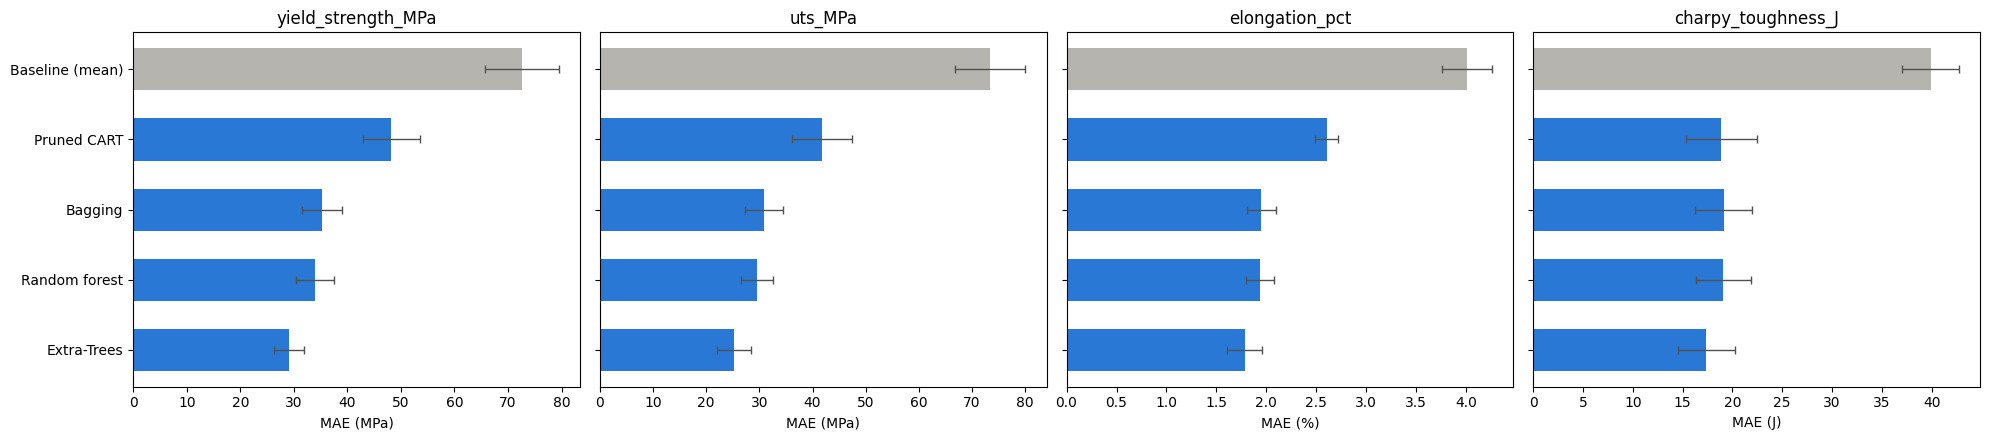

In [4]:
units = {"yield_strength_MPa": "MPa", "uts_MPa": "MPa", "elongation_pct": "%", "charpy_toughness_J": "J"}

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)
for ax, target in zip(axes, TARGETS):
    rows = overall.xs(target, level="target").reindex(models)
    ax.barh(models, rows["MAE"], xerr=rows["MAE_std"], height=0.6, color=["#b5b4ae"] + ["#2a78d6"] * 4,
            error_kw={"ecolor": "#52514e", "elinewidth": 1, "capsize": 3})
    ax.set_title(target)
    ax.set_xlabel(f"MAE ({units[target]})")
axes[0].invert_yaxis()
plt.tight_layout()
plt.show()

The error bars are the standard deviation of the MAE over the 5 folds (`MAE_std`).

- **Tensile targets:** On the yield strength and the UTS, the gaps between the pruned tree and the ensembles, and between the random forest and the Extra-Trees, are larger than the standard deviation. The bagging and the random forest overlap on every target.
- **Charpy:** The four tree models overlap, only the baseline is clearly behind.
- **Shared folds:** Every model uses the same folds, so part of this standard deviation is shared: some folds are harder for every model. The error bars therefore overstate the uncertainty of the gap between two models.

In [5]:
per_family = results["MAE"].unstack("model").reindex(
    index=pd.MultiIndex.from_product([TARGETS, REPORT_FAMILIES], names=["target", "family"]),
    columns=models,
)
per_family.insert(0, "n", results.xs("Baseline (mean)", level="model")["n"])
per_family.round(2)

model                        n  Baseline (mean)  Pruned CART  Bagging  \
target             family                                               
yield_strength_MPa all     620            72.57        48.24    35.24   
                   C-Mn    552            68.25        46.65    33.49   
                   CrMo2    30            65.15        93.12    55.38   
                   CrMo91   38           141.25        35.90    44.78   
uts_MPa            all     596            73.45        41.78    30.86   
                   C-Mn    531            68.13        40.31    29.26   
                   CrMo2    34            80.85        61.37    50.13   
                   CrMo91   31           156.29        45.57    37.09   
elongation_pct     all     558             4.01         2.60     1.95   
                   C-Mn    497             3.76         2.61     1.94   
                   CrMo2    30             5.19         2.66     2.37   
                   CrMo91   31             6.83         2.51     1.60   
charpy_toughness_J all     723            39.89        18.87    19.11   
                   C-Mn    613            35.78        16.18    16.08   
                   CrMo2    77            71.26        40.81    44.43   
                   CrMo91   33            42.97        17.68    16.33   

model                      Random forest  Extra-Trees  
target             family                              
yield_strength_MPa all             33.95        29.08  
                   C-Mn            32.08        27.08  
                   CrMo2           54.21        44.72  
                   CrMo91          45.12        45.72  
uts_MPa            all             29.55        25.24  
                   C-Mn            27.84        23.12  
                   CrMo2           48.50        45.74  
                   CrMo91          38.04        38.93  
elongation_pct     all              1.94         1.78  
                   C-Mn             1.93         1.76  
                   CrMo2            2.41         2.60  
                   CrMo91           1.61         1.41  
charpy_toughness_J all             19.09        17.37  
                   C-Mn            15.75        13.87  
                   CrMo2           46.85        46.30  
                   CrMo91          16.27        14.72

`n` is the number of rows where the target is measured, in the family.

- **C-Mn:** The same ranking as on all the welds, with the Extra-Trees at 27.1 MPa on the yield strength and 13.9 J on Charpy.
- **CrMo2:** The hardest family for every model. The pruned tree is above the baseline on the yield strength (93.1 against 65.2 MPa), the ensembles below it (44.7 to 55.4 MPa). On Charpy, the tree models stay between 40.8 and 46.9 J, against 13.9 to 16.2 J on the C-Mn welds.
- **CrMo91:** The pruned tree has the lowest MAE on the yield strength (35.9 against 44.8 to 45.7 MPa), but on 38 rows with a standard deviation of 18 to 22 MPa over the folds, so the gap is not significant. The ensembles are better on the UTS and the elongation.

In [6]:
display(overall[["F1_nc", "recall_nc", "accuracy", "precision_good"]].unstack().reindex(index=models).reindex(columns=TARGETS + ["label"], level="target").round(2))

label = results.xs("label", level="target")
label[["F1_nc", "recall_nc", "accuracy", "precision_good"]].unstack("family").reindex(index=models).reindex(columns=REPORT_FAMILIES, level="family").round(2)

F1_nc                                            \
target          yield_strength_MPa uts_MPa elongation_pct charpy_toughness_J   
model                                                                          
Baseline (mean)               0.00    0.00           0.00               0.00   
Pruned CART                   0.60    0.64           0.46               0.52   
Bagging                       0.68    0.67           0.62               0.17   
Random forest                 0.63    0.68           0.59               0.26   
Extra-Trees                   0.78    0.74           0.72               0.27   

                               recall_nc                         \
target          label yield_strength_MPa uts_MPa elongation_pct   
model                                                             
Baseline (mean)  0.00               0.00    0.00           0.00   
Pruned CART      0.77               0.60    0.63           0.50   
Bagging          0.81               0.57    0.56           0.50   
Random forest    0.76               0.48    0.54           0.44   
Extra-Trees      0.84               0.65    0.61           0.60   

                                                   accuracy          \
target          charpy_toughness_J label yield_strength_MPa uts_MPa   
model                                                                 
Baseline (mean)               0.00  0.00               0.84    0.67   
Pruned CART                   0.62  0.81               0.87    0.76   
Bagging                       0.10  0.72               0.91    0.82   
Random forest                 0.17  0.64               0.91    0.83   
Extra-Trees                   0.17  0.72               0.94    0.86   

                                                            precision_good  \
target          elongation_pct charpy_toughness_J label yield_strength_MPa   
model                                                                        
Baseline (mean)           0.91               0.91  0.53               0.84   
Pruned CART               0.90               0.90  0.77               0.92   
Bagging                   0.95               0.91  0.84               0.92   
Random forest             0.95               0.91  0.81               0.91   
Extra-Trees               0.96               0.91  0.87               0.93   

                                                                 
target          uts_MPa elongation_pct charpy_toughness_J label  
model                                                            
Baseline (mean)    0.67           0.91               0.91  0.53  
Pruned CART        0.82           0.95               0.96  0.81  
Bagging            0.81           0.95               0.92  0.79  
Random forest      0.81           0.95               0.92  0.75  
Extra-Trees        0.83           0.96               0.92  0.80

F1_nc                    recall_nc                     \
family            all  C-Mn CrMo2 CrMo91       all  C-Mn CrMo2 CrMo91   
model                                                                   
Baseline (mean)  0.00  0.00   0.0    0.0      0.00  0.00   0.0   0.00   
Pruned CART      0.77  0.78   1.0    0.0      0.81  0.84   1.0   0.00   
Bagging          0.81  0.83   0.0    0.5      0.72  0.75   0.0   0.33   
Random forest    0.76  0.77   0.0    0.5      0.64  0.66   0.0   0.33   
Extra-Trees      0.84  0.85   0.0    0.8      0.72  0.73   0.0   0.67   

                accuracy                    precision_good                     
family               all  C-Mn CrMo2 CrMo91            all  C-Mn CrMo2 CrMo91  
model                                                                          
Baseline (mean)     0.53  0.51  0.88   0.50           0.53  0.51  0.88   0.50  
Pruned CART         0.77  0.77  1.00   0.33           0.81  0.82  1.00   0.40  
Bagging             0.84  0.84  0.88   0.67           0.79  0.79  0.88   0.60  
Random forest       0.81  0.81  0.88   0.67           0.75  0.74  0.88   0.60  
Extra-Trees         0.87  0.87  0.88   0.83           0.80  0.80  0.88   0.75

The first table gives the F1 and the recall on the non-conforming welds for each criterion (on the rows where it is decided) and for the full label (on the 175 labelled deposits). The second gives the label per family.

- **Tensile criteria:** The Extra-Trees have the best F1 on the three (0.78, 0.74 and 0.72). The recall stays between 0.44 and 0.65 for every model: a third to a half of the non-conforming tensile results are missed.
- **Charpy:** Only the pruned tree catches the non-conforming rows (recall of 0.62). The ensembles catch 3 to 5 of the 29 (recall of 0.10 to 0.17): their predictions at the reference temperature are the mean of 200 trees and rarely fall below the threshold (see the tables of the spread of the predictions in each notebook).
- **label:** F1 from 0.76 (random forest) to 0.84 (Extra-Trees), all above the 0.64 of the rule that declares every weld non-conforming. The pruned tree has the best recall (0.81) thanks to Charpy, the Extra-Trees the best F1.
- **Per family:** The 161 C-Mn deposits give the same ranking. The Cr-Mo values rely on 8 and 6 deposits (1 and 3 non-conforming): one deposit changes the F1 a lot, so they are not used to compare the models.